In [10]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [6]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

In [7]:
trainset = datasets.MNIST(root="./data", train = True, download = True, transform = transform)
testset = datasets.MNIST(root="./data", train = False, download = True, transform = transform)

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9.91M/9.91M [00:04<00:00, 2.14MB/s]
100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 28.9k/28.9k [00:00<00:00, 247kB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1.65M/1.65M [00:01<00:00, 1.01MB/s]
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4.54k/4.54k [00:00<00:00, 1.85MB/s]


In [8]:
trainset

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [9]:
testset

Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: Compose(
               ToTensor()
               Normalize(mean=(0.5,), std=(0.5,))
           )

In [11]:
# Dataloader
train_loader = DataLoader(trainset, batch_size = 64, shuffle = True)
test_loader = DataLoader(testset, batch_size = 64, shuffle = True)

# Build CNN

In [18]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__() # initializes the parent nn.Module class
 
        # ----- Feature extraction (Conv -> ReLU -> Pool), x3 -----
        self.conv_layers = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size = 3, padding = 1),
            # in_channels=1  -> MNIST images are grayscale (1 channel, not 3 like RGB)
            # out_channels=32 -> use 32 different learnable kernels (pattern detectors)
            # kernel_size=3  -> each kernel is a 3x3 sliding stencil
            # padding=1      -> pads image so output spatial size stays same as input (28x28 -> 28x28)
            
            nn.ReLU(), # zeroes out negative values, adds non-linearity so the network isn't just linear math
            nn.MaxPool2d(2,2), # kernel_size=2, stride=2 -> shrinks spatial size by half: 28x28 -> 14x1

            # Block 2
            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            # in_channels=32 -> MUST match previous layer's out_channels (32 feature maps coming in)
            # out_channels=64 -> now detecting 64 more complex patterns, built on top of the 32 simple ones
            
            nn.ReLU(),
            nn.MaxPool2d(2,2), # 14x14 -> 7x7

            # Block 3
            nn.Conv2d(64, 128, kernel_size = 3, padding = 1),
            # in_channels=64  -> matches previous out_channels
            # out_channels=128 -> even more abstract, high-level features
            
            nn.ReLU(),
            nn.MaxPool2d(2,2)  #7x7 -> 3x3 (7/2 = 3.5, PyTorch floors this down to 3 - NOT a clean power-of-2 division)
        )
        self.fc_layers = nn.Sequential(
            nn.Linear(3*3*128, 256), 
             # input size = 3*3*128 = 1152 -> total flattened numbers coming out of conv_layers
            # output size = 256 -> a chosen hidden layer size (independent design choice,
            #                      unrelated to the "128" channels above)
            nn.ReLU(),
            nn.Linear(256, 10)
            # input size = 128 -> must match previous layer's output size
            # output size = 10 -> one score (logit) per digit class: 0 through 9
        )

    def forward(self, x):
        # x starts as shape (batch_size, 1, 28, 28)
        x = self.conv_layers(x)
        # x becomes shape (batch_size, 128, 3, 3) after all conv + pool blocks
        x = x.view(x.size(0), -1)
        # flattening step: reshapes (batch_szie 128, 3, 3)  --> (batch_size, 1152)
        # x.size(0) keeps the batch dimension unchanged; -1 tells PyTorch to
        # automatically flatten everything else into one long dimension
        x = self.fc_layers(x)
        # x becomes shape (batch_size, 10) -> raw scores (logits) for each digit class
        return x
        # softmax is not applied here - nn.CrossEntropyLoss applies it internally during training

In [19]:
model = CNN()

In [25]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())

# Training the CNN

In [27]:
epochs = 10
train_losses = []
val_losses = []
best_val_loss = float("inf")

for epoch in range(epochs):
    # Training
    model.train()
    epoch_running_loss = 0.0
    for xb, yb in train_loader:
        optimizer.zero_grad()
        output = model(xb) # FP
        loss = criterion(output, yb) # loss fnx
        loss.backward() # Bp
        optimizer.step() # update params
        epoch_running_loss += loss.item()
    epoch_training_loss = epoch_running_loss / len(train_loader)
    train_losses.append(epoch_training_loss)

    # Validation
    model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss
        epoch_val_loss = running_val_loss/len(test_loader)
        val_losses.append(epoch_val_loss)
        
    print(f"Epoch {epoch + 1}/{epochs}, ===>> Train Loss = {epoch_training_loss:.4f}, Val Loss = {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

Epoch 1/10, ===>> Train Loss = 0.0198, Val Loss = 0.0219
Epoch 2/10, ===>> Train Loss = 0.0165, Val Loss = 0.0261
Epoch 3/10, ===>> Train Loss = 0.0146, Val Loss = 0.0341
Epoch 4/10, ===>> Train Loss = 0.0105, Val Loss = 0.0288
Epoch 5/10, ===>> Train Loss = 0.0090, Val Loss = 0.0300
Epoch 6/10, ===>> Train Loss = 0.0098, Val Loss = 0.0334
Epoch 7/10, ===>> Train Loss = 0.0073, Val Loss = 0.0371
Epoch 8/10, ===>> Train Loss = 0.0087, Val Loss = 0.0331
Epoch 9/10, ===>> Train Loss = 0.0075, Val Loss = 0.0357
Epoch 10/10, ===>> Train Loss = 0.0066, Val Loss = 0.0422


In [29]:
# Evaluate the model
from sklearn.metrics import accuracy_score, confusion_matrix

mode = CNN()
model.load_state_dict(torch.load("best_model.pt"))
model.eval()
all_preds = []
all_actuals = []

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.tolist())
        all_actuals.extend(yb.tolist())
# Accuracy socre
print(f"Accuracy score: {accuracy_score(all_actuals, all_preds)}")

# Confusion matrix
cm = confusion_matrix(all_actuals, all_preds)
print("\nConfusion Matrix")
print(cm)

    

Accuracy score: 0.9936

Confusion Matrix
[[ 975    0    0    0    1    0    2    1    1    0]
 [   3 1130    0    0    0    0    0    2    0    0]
 [   0    0 1027    0    1    0    0    3    1    0]
 [   0    0    1 1004    0    2    0    1    1    1]
 [   0    0    0    0  976    0    1    0    1    4]
 [   1    0    1    4    0  885    1    0    0    0]
 [   2    2    0    0    1    1  951    0    1    0]
 [   0    3    0    0    0    0    0 1022    1    2]
 [   2    0    1    1    0    0    0    0  970    0]
 [   0    0    0    0    5    6    0    0    2  996]]


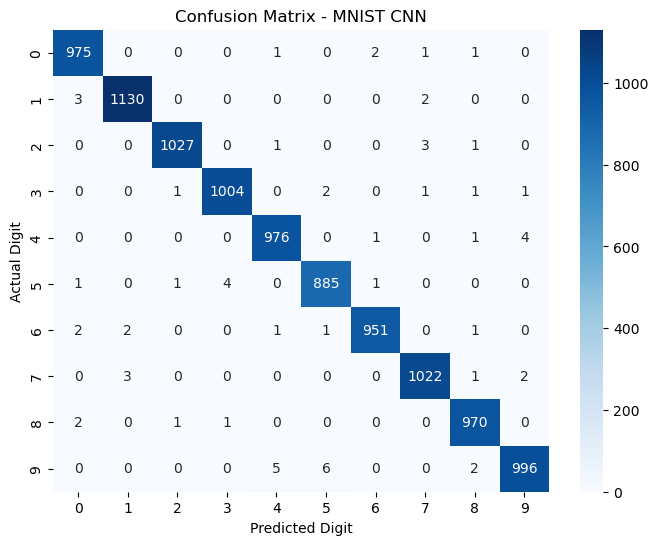

<Figure size 640x480 with 0 Axes>

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize = (8,6))
sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues", xticklabels=range(10), yticklabels=range(10))

plt.xlabel("Predicted Digit")
plt.ylabel("Actual Digit")
plt.title("Confusion Matrix - MNIST CNN")
plt.show()
plt.tight_layout()